# 🚗 Road Surface Damage Detection — YOLOv8 Training

**Dataset:** [Road Damage Dataset (Kaggle)](https://www.kaggle.com/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes)  
**Model:** YOLOv8s (Ultralytics)  
**Classes:** `0: pothole` | `1: crack` | `2: manhole`

---
### ⚠️ Before You Start
1. **Enable GPU**: Runtime → Change runtime type → **T4 GPU**
2. **Get Kaggle key**: [kaggle.com/settings](https://www.kaggle.com/settings) → API → Create New Token → Download `kaggle.json`
3. Run cells **top to bottom** in order
---

## 📦 Step 1 — Install Dependencies

In [1]:
# Install all required packages
!pip install ultralytics==8.2.0 --quiet
!pip install kaggle --quiet
!pip install opencv-python-headless --quiet
!pip install albumentations --quiet

import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU — go to Runtime > Change runtime type > T4 GPU')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.8/750.8 kB 15.5 MB/s eta 0:00:00
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


In [2]:
import os, shutil, json, yaml, random, cv2, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from pathlib import Path
from ultralytics import YOLO
print('✅ Imports OK')

✅ Imports OK


## 📁 Step 2 — Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/road_damage_detection'
os.makedirs(f'{DRIVE_DIR}/models', exist_ok=True)
os.makedirs(f'{DRIVE_DIR}/results', exist_ok=True)
print(f'✅ Drive mounted — project folder: {DRIVE_DIR}')

Mounted at /content/drive
✅ Drive mounted — project folder: /content/drive/MyDrive/road_damage_detection


## 📥 Step 3 — Download Dataset from Kaggle

In [4]:
from google.colab import files

print('📤 Upload your kaggle.json API key file:')
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded['kaggle.json'])
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('✅ Kaggle credentials configured')

📤 Upload your kaggle.json API key file:


Saving kaggle.json to kaggle.json
✅ Kaggle credentials configured


In [5]:
DATASET_DIR = '/content/road_damage_raw'
os.makedirs(DATASET_DIR, exist_ok=True)

print('⬇️  Downloading dataset...')
!kaggle datasets download \
    -d lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes \
    -p {DATASET_DIR} --unzip

# Show structure (2 levels)
for root, dirs, flist in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, '').count(os.sep)
    if level > 2: continue
    print('  ' * level + os.path.basename(root) + '/')
    if level < 2:
        for f in flist[:3]: print('  ' * (level+1) + f)

⬇️  Downloading dataset...
Dataset URL: https://www.kaggle.com/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes
License(s): MIT
100% 185M/185M [00:01<00:00, 122MB/s]

road_damage_raw/
  data/
    YOLO-conversion-script.py
    README.md
    COCO-conversion-script.py
    images/
    labels/
    labels-YOLO/


## 🗂️ Step 4 — Prepare Dataset

In [6]:
PROJECT_DIR  = '/content/road_damage_project'
DATA_DIR     = f'{PROJECT_DIR}/data'
CLASS_NAMES  = ['pothole', 'crack', 'manhole']
TRAIN_RATIO  = 0.75
VAL_RATIO    = 0.15
# test = remaining 10%

for split in ['train', 'val', 'test']:
    os.makedirs(f'{DATA_DIR}/{split}/images', exist_ok=True)
    os.makedirs(f'{DATA_DIR}/{split}/labels', exist_ok=True)

print(f'✅ Directory structure created under {PROJECT_DIR}')

✅ Directory structure created under /content/road_damage_project


In [7]:
def find_pairs(base_dir):
    exts = {'.jpg', '.jpeg', '.png'}
    pairs = []
    for root, _, files in os.walk(base_dir):
        for f in files:
            if Path(f).suffix.lower() in exts:
                img = Path(root) / f
                lbl = img.with_suffix('.txt')
                if not lbl.exists():
                    lbl = Path(str(img).replace('images','labels')).with_suffix('.txt')
                if lbl.exists():
                    pairs.append((str(img), str(lbl)))
    return pairs

def validate_label(path):
    try:
        with open(path) as f:
            for line in f:
                p = line.strip().split()
                if not p: continue
                if len(p) != 5: return False
                c,x,y,w,h = int(p[0]),*map(float,p[1:])
                if c not in [0,1,2]: return False
                if not (0<=x<=1 and 0<=y<=1 and 0<w<=1 and 0<h<=1): return False
    except: return False
    return True

all_pairs = find_pairs(DATASET_DIR)
valid_pairs = [p for p in all_pairs if validate_label(p[1])]
print(f'Found  : {len(all_pairs)} image-label pairs')
print(f'Valid  : {len(valid_pairs)} pairs')
print(f'Invalid: {len(all_pairs)-len(valid_pairs)} pairs (skipped)')

Found  : 2009 image-label pairs
Valid  : 0 pairs
Invalid: 2009 pairs (skipped)


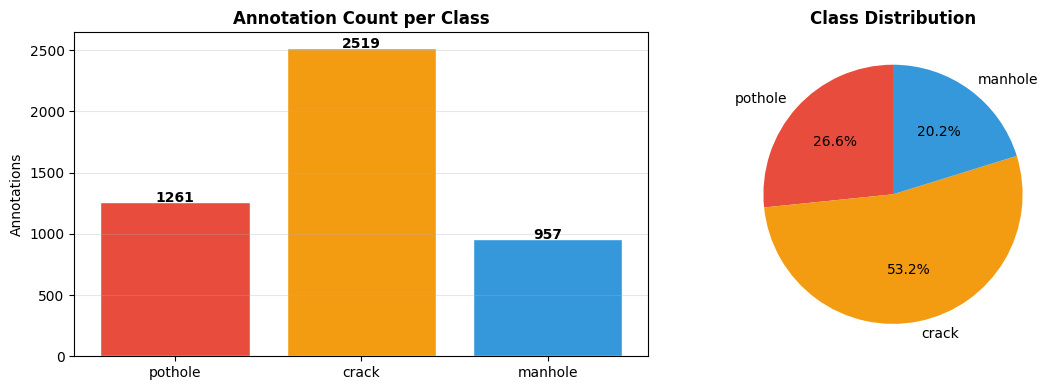

Total annotations: 4737


In [8]:
# Count annotations per class
counts = {0:0, 1:0, 2:0}
for _, lbl in all_pairs:
    with open(lbl) as f:
        for line in f:
            p = line.strip().split()
            if p: counts[int(p[0])] = counts.get(int(p[0]),0) + 1

# Check if there are any annotations before plotting
total_annotations = sum(counts.values())
if total_annotations == 0:
    print("No valid annotations found. Skipping class distribution plots.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = ['#E74C3C', '#F39C12', '#3498DB']
    axes[0].bar(CLASS_NAMES, [counts[i] for i in range(3)], color=colors, edgecolor='white')
    axes[0].set_title('Annotation Count per Class', fontweight='bold')
    axes[0].set_ylabel('Annotations')
    axes[0].grid(axis='y', alpha=0.3)
    for i, v in enumerate([counts[i] for i in range(3)]):
        axes[0].text(i, v+2, str(v), ha='center', fontweight='bold')

    axes[1].pie([counts[i] for i in range(3)], labels=CLASS_NAMES, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Class Distribution', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
print(f'Total annotations: {total_annotations}')

In [9]:
random.seed(42)
random.shuffle(all_pairs)

n = len(all_pairs)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)
splits  = {'train': all_pairs[:n_train],
           'val':   all_pairs[n_train:n_train+n_val],
           'test':  all_pairs[n_train+n_val:]}

for name, pairs in splits.items():
    for img_p, lbl_p in pairs:
        shutil.copy2(img_p, f'{DATA_DIR}/{name}/images/{Path(img_p).name}')
        shutil.copy2(lbl_p, f'{DATA_DIR}/{name}/labels/{Path(lbl_p).name}')
    if n > 0:
        print(f'  {name:6s}: {len(pairs):4d} images ({len(pairs)/n*100:.1f}%)')
    else:
        print(f'  {name:6s}: {len(pairs):4d} images (0.0%)')

# Write YAML
yaml_path = f'{PROJECT_DIR}/road_damage.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump({'path': DATA_DIR, 'train':'train/images', 'val':'val/images',
               'test':'test/images', 'nc':3, 'names': CLASS_NAMES}, f)
print(f'\n✅ YAML written to {yaml_path}')

  train : 1506 images (75.0%)
  val   :  301 images (15.0%)
  test  :  202 images (10.1%)

✅ YAML written to /content/road_damage_project/road_damage.yaml


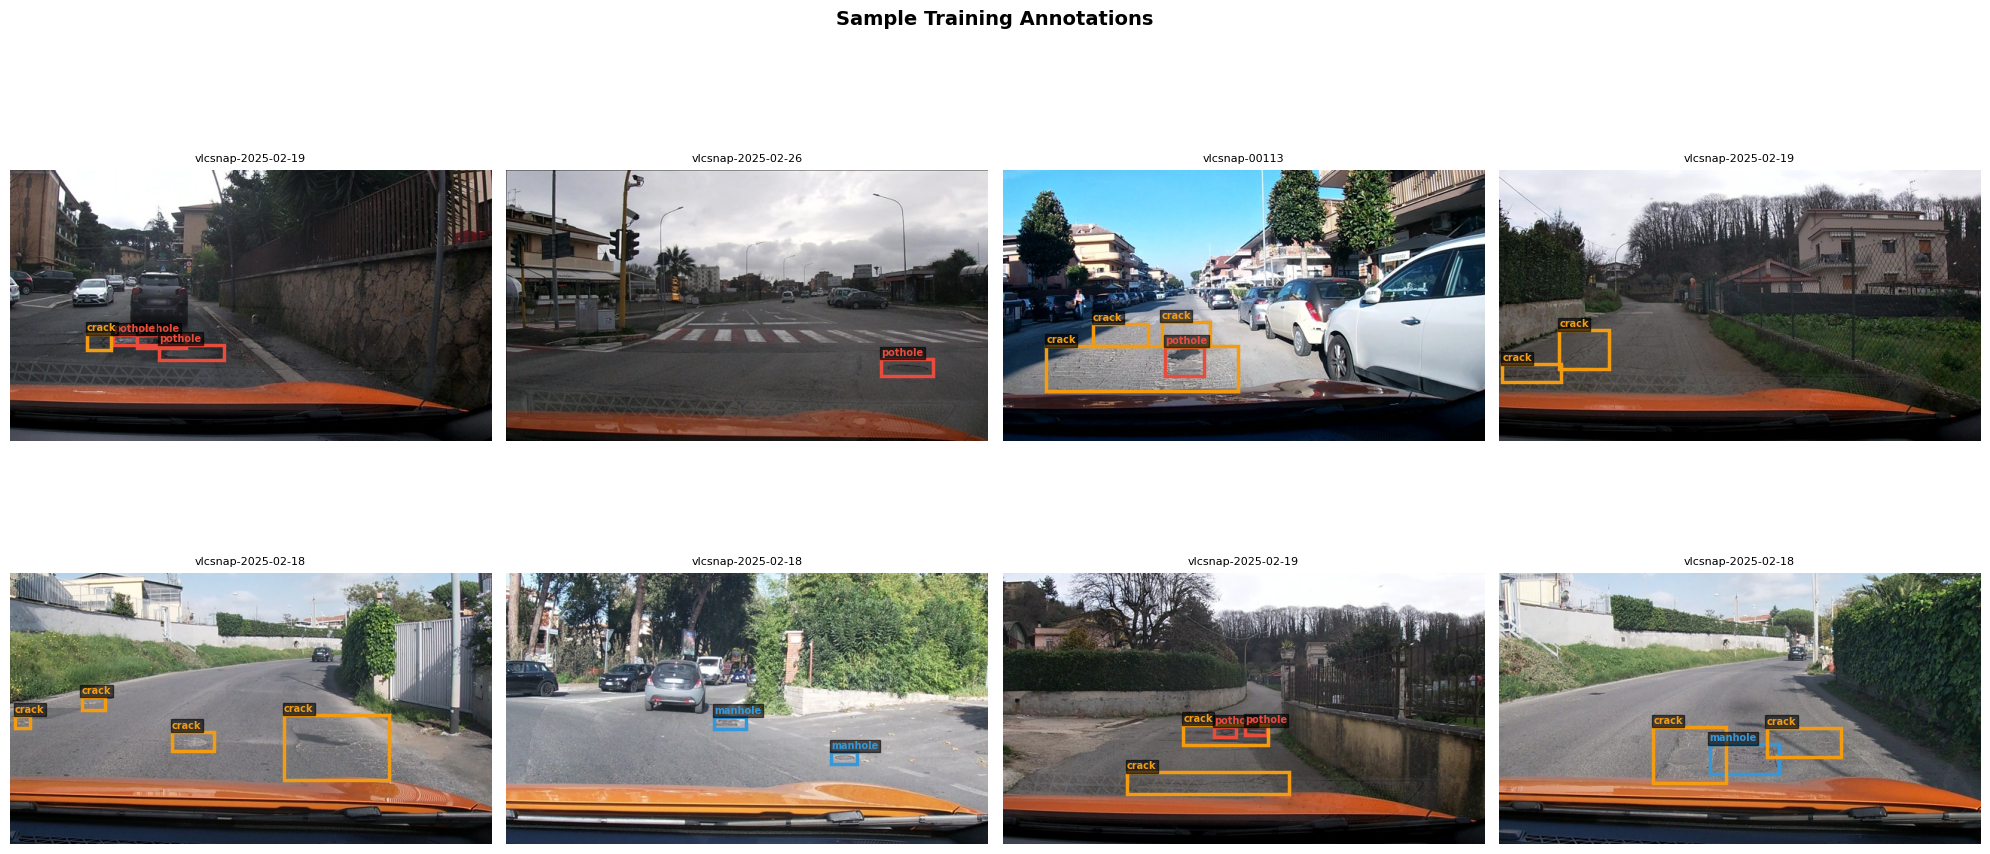

In [10]:
def draw_yolo_boxes(img_p, lbl_p):
    img = cv2.cvtColor(cv2.imread(img_p), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    fig, ax = plt.subplots(figsize=(5,4))
    ax.imshow(img)
    color_map = {0:'#E74C3C', 1:'#F39C12', 2:'#3498DB'}
    with open(lbl_p) as f:
        for line in f:
            p = line.strip().split()
            if not p: continue
            # Original error: c,cx,cy,bw,bh = int(p[0]),*map(float,p[1:])
            # Fixed to handle polygon (segmentation) format
            c = int(p[0])
            coords = list(map(float, p[1:]))

            # Calculate bounding box from polygon points
            xs = coords[0::2]
            ys = coords[1::2]
            min_x, max_x = min(xs), max(xs)
            min_y, max_y = min(ys), max(ys)

            cx = (min_x + max_x) / 2
            cy = (min_y + max_y) / 2
            bw = max_x - min_x
            bh = max_y - min_y

            x1,y1 = (cx-bw/2)*w, (cy-bh/2)*h
            ax.add_patch(patches.Rectangle((x1,y1),bw*w,bh*h,
                linewidth=2.5, edgecolor=color_map.get(c,'white'), facecolor='none'))
            ax.text(x1, y1-4, CLASS_NAMES[c], color=color_map.get(c,'white'),
                fontsize=8, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.6, pad=1))
    ax.axis('off')
    return fig

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
samples = random.sample(splits['train'][:50], 8)
for ax, (ip, lp) in zip(axes.flatten(), samples):
    img = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)
    color_map = {0:'#E74C3C', 1:'#F39C12', 2:'#3498DB'}
    with open(lp) as f:
        for line in f:
            p = line.strip().split()
            if not p: continue
            # Original error: c,cx,cy,bw,bh = int(p[0]),*map(float,p[1:])
            # Fixed to handle polygon (segmentation) format
            c = int(p[0])
            coords = list(map(float, p[1:]))

            # Calculate bounding box from polygon points
            xs = coords[0::2]
            ys = coords[1::2]
            min_x, max_x = min(xs), max(xs)
            min_y, max_y = min(ys), max(ys)

            cx = (min_x + max_x) / 2
            cy = (min_y + max_y) / 2
            bw = max_x - min_x
            bh = max_y - min_y

            x1,y1 = (cx-bw/2)*w, (cy-bh/2)*h
            ax.add_patch(patches.Rectangle((x1,y1),bw*w,bh*h,
                linewidth=2.5, edgecolor=color_map.get(c,'white'), facecolor='none'))
            ax.text(x1, max(y1-4,0), CLASS_NAMES[c],
                color=color_map.get(c,'white'), fontsize=7, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.6, pad=1))
    ax.set_title(Path(ip).stem[:18], fontsize=8)
    ax.axis('off')

plt.suptitle('Sample Training Annotations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/sample_annotations.png', dpi=150, bbox_inches='tight')
plt.show()

## 🚀 Step 5 — Train YOLOv8s

> ⏱️ Expected time: **40–60 min** on T4 GPU

In [20]:
CFG = dict(
    data        = yaml_path,
    model       = 'yolov8m.pt',   # change to yolov8m.pt for better accuracy
    epochs      = 100,
    imgsz       = 640,
    batch       = 16,             # reduce to 8 if OOM
    lr0         = 0.01,
    lrf         = 0.001,
    momentum    = 0.937,
    weight_decay= 0.0005,
    warmup_epochs=3,
    mosaic      = 1.0,
    mixup       = 0.1,
    copy_paste  = 0.1,
    degrees     = 15.0,
    translate   = 0.1,
    scale       = 0.5,
    flipud      = 0.3,
    fliplr      = 0.5,
    hsv_h       = 0.015,
    hsv_s       = 0.7,
    hsv_v       = 0.4,
    optimizer   = 'AdamW',
    patience    = 20,
    save_period = 10,
    project     = 'road_damage_detection', # Changed from file path to simple project name
    name        = 'road_damage_v1',
    exist_ok    = True,
    pretrained  = True,
    verbose     = True,
    seed        = 42,
    device      = 0 if torch.cuda.is_available() else 'cpu',
    workers     = 2,
)

print('Training configuration:')
for k,v in CFG.items(): print(f'  {k:<16}: {v}')

Training configuration:
  data            : /content/road_damage_project/road_damage.yaml
  model           : yolov8m.pt
  epochs          : 100
  imgsz           : 640
  batch           : 16
  lr0             : 0.01
  lrf             : 0.001
  momentum        : 0.937
  weight_decay    : 0.0005
  warmup_epochs   : 3
  mosaic          : 1.0
  mixup           : 0.1
  copy_paste      : 0.1
  degrees         : 15.0
  translate       : 0.1
  scale           : 0.5
  flipud          : 0.3
  fliplr          : 0.5
  hsv_h           : 0.015
  hsv_s           : 0.7
  hsv_v           : 0.4
  optimizer       : AdamW
  patience        : 20
  save_period     : 10
  project         : road_damage_detection
  name            : road_damage_v1
  exist_ok        : True
  pretrained      : True
  verbose         : True
  seed            : 42
  device          : 0
  workers         : 2


In [21]:
import torch.serialization
from ultralytics.nn.tasks import DetectionModel
import torch.nn
from ultralytics.nn.modules import Conv # Import the Conv module
import os

# Keep add_safe_globals as suggested by error message, although forcing weights_only=False is more direct.
torch.serialization.add_safe_globals([DetectionModel, torch.nn.modules.container.Sequential, Conv])

# Store the original torch.load function
original_torch_load = torch.load

# Define a patched torch.load function to force weights_only=False
def patched_torch_load(*args, **kwargs):
    # Ensure weights_only is set to False, addressing PyTorch 2.6+ default behavior
    if 'weights_only' not in kwargs or kwargs['weights_only'] is True:
        kwargs['weights_only'] = False
    return original_torch_load(*args, **kwargs)

# Temporarily replace torch.load with the patched version
torch.load = patched_torch_load

# Create a copy of CFG to avoid modifying the original dictionary if cell is re-run
train_cfg = CFG.copy()

# Ensure 'model' key exists in train_cfg, providing a default if missing
if 'model' not in train_cfg:
    print("Warning: 'model' key not found in CFG. Using default 'yolov8s.pt'.")
    train_cfg['model'] = 'yolov8m.pt' # Set a default if it's somehow missing

model_name = train_cfg.pop('model') # Get model name and remove from train_cfg

# Disable Weights & Biases logging to prevent interactive prompts
os.environ['WANDB_MODE'] = 'offline'

try:
    model = YOLO(model_name)  # load pretrained weights
    results = model.train(**train_cfg)
except Exception as e:
    # Restore original torch.load in case of error during model loading
    torch.load = original_torch_load
    raise e
finally:
    # Always restore original torch.load after model loading is done
    torch.load = original_torch_load

print('\n✅ Training Complete!')
print(f"  Best mAP@50    : {results.results_dict.get('metrics/mAP50(B)', 0):.4f}")
print(f"  Best mAP@50-95 : {results.results_dict.get('metrics/mAP50-95(B)', 0):.4f}")

100%|██████████| 49.7M/49.7M [00:00<00:00, 62.7MB/s]


New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/road_damage_project/road_damage.yaml, epochs=100, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=10, cache=False, device=0, workers=2, project=road_damage_detection, name=road_damage_v1, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_m

train: Scanning /content/road_damage_project/data/train/labels.cache... 1506 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1506/1506 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



/usr/local/lib/python3.12/dist-packages/ultralytics/data/augment.py:891: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
val: Scanning /content/road_damage_project/data/val/labels.cache... 301 images, 0 backgrounds, 0 corrupt: 100%|██████████| 301/301 [00:00<?, ?it/s]


...


100 epochs completed in 1.880 hours.
Optimizer stripped from road_damage_detection/road_damage_v1/weights/last.pt, 52.0MB
Optimizer stripped from road_damage_detection/road_damage_v1/weights/best.pt, 52.0MB

Validating road_damage_detection/road_damage_v1/weights/best.pt...
Ultralytics YOLOv8.2.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 218 layers, 25841497 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [00:04<00:00,  2.38it/s]


                   all        301        692      0.453      0.496      0.476      0.206
               pothole        301        194      0.469       0.31      0.373      0.164
                 crack        301        377      0.401      0.334      0.301      0.106
               manhole        301        121      0.487      0.843      0.754      0.349
Speed: 0.1ms preprocess, 6.0ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to road_damage_detection/road_damage_v1


lr/pg0,█▅▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▃▅██▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
lr/pg2,█████▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
metrics/mAP50(B),▁▁▂▃▃▃▄▄▅▅▄▆▅▅▅▆▅▆▆▆▆▆▆▆▆▇▆▇▇▇▇▇█▇▇█████
metrics/mAP50-95(B),▁▂▂▂▃▂▃▃▃▄▄▄▄▄▄▅▅▆▅▅▅▆▅▅▆▆▇▇▇▇▇▇▇▇██████
metrics/precision(B),▁▂▄▃▇▄▄▄▄▃▅▅▅▅▆▅▆▆▆▆▆▇▇▆▇▇▇▇█▆▇██▇█▇▇███
metrics/recall(B),▁▁▄▅▄▄▄▄▅▅▆▅▆▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█▇███▇██▇▇█
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...



✅ Training Complete!
  Best mAP@50    : 0.4762
  Best mAP@50-95 : 0.2064


## 📈 Step 6 — Visualize Training Curves

In [1]:
RUNS_DIR = "/road_damage_detection/road_damage_v1"
results_csv = f'{RUNS_DIR}/results.csv'

df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('YOLOv8 Training Metrics — Road Damage Detection',
             fontsize=14, fontweight='bold')

plots = [
    ('train/box_loss',      'Train Box Loss',    '#E74C3C'),
    ('train/cls_loss',      'Train Class Loss',  '#E74C3C'),
    ('train/dfl_loss',      'Train DFL Loss',    '#E74C3C'),
    ('val/box_loss',        'Val Box Loss',      '#2ECC71'),
    ('val/cls_loss',        'Val Class Loss',    '#2ECC71'),
    ('val/dfl_loss',        'Val DFL Loss',      '#2ECC71'),
    ('metrics/mAP50(B)',    'mAP@50',            '#3498DB'),
    ('metrics/mAP50-95(B)', 'mAP@50-95',         '#3498DB'),
]

for ax, (col, title, color) in zip(axes.flatten(), plots):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], color=color, lw=2)
        ax.fill_between(df['epoch'], df[col], alpha=0.12, color=color)
        if 'mAP' in col:
            best = df[col].idxmax()
            ax.axvline(df['epoch'][best], color='gold', ls='--', alpha=0.7)
            ax.scatter(df['epoch'][best], df[col][best], color='gold', s=80, zorder=5)
            ax.text(df['epoch'][best], df[col][best], f' {df[col][best]:.4f}',
                    fontsize=8, color='gold')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved')

NameError: name 'pd' is not defined

## 🧪 Step 7 — Validate & Run Test Predictions

In [ ]:
best_pt = f'{RUNS_DIR}/weights/best.pt'
best_model = YOLO(best_pt)

print('Running validation on val split...')
val_results = best_model.val(
    data=yaml_path, split='val', imgsz=640, batch=16,
    conf=0.25, iou=0.6, verbose=True
)

print('\n📊 Validation Results:')
for k, v in val_results.results_dict.items():
    print(f'  {k:<40}: {v:.4f}')

In [ ]:
test_imgs = list(Path(f'{DATA_DIR}/test/images').glob('*.jpg')) + \
            list(Path(f'{DATA_DIR}/test/images').glob('*.png'))

samples = random.sample(test_imgs, min(8, len(test_imgs)))
color_map = {0:(231/255,76/255,60/255), 1:(243/255,156/255,18/255), 2:(52/255,152/255,219/255)}

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Test Set Predictions', fontsize=14, fontweight='bold')

for ax, ip in zip(axes.flatten(), samples):
    preds = best_model.predict(str(ip), conf=0.25, iou=0.45, verbose=False)
    img = cv2.cvtColor(cv2.imread(str(ip)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    for box in preds[0].boxes:
        x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()
        c = int(box.cls[0]); conf = float(box.conf[0])
        color = color_map.get(c,(1,1,1))
        ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
            lw=2, edgecolor=color, facecolor='none'))
        ax.text(x1, max(y1-4,0), f'{CLASS_NAMES[c]} {conf:.2f}',
            color='white', fontsize=7, fontweight='bold',
            bbox=dict(facecolor=color, alpha=0.85, pad=1))
    ax.set_title(f'{Path(ip).stem[:16]} ({len(preds[0].boxes)} det.)', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Test predictions visualized')

## 💾 Step 8 — Export Model to Google Drive

In [ ]:
# Copy model weights to Drive
shutil.copy2(best_pt, f'{DRIVE_DIR}/models/best.pt')
shutil.copy2(f'{RUNS_DIR}/weights/last.pt', f'{DRIVE_DIR}/models/last.pt')

# Copy visualizations
for fname in ['class_distribution.png','sample_annotations.png',
              'training_curves.png','test_predictions.png']:
    src = f'{PROJECT_DIR}/{fname}'
    if os.path.exists(src):
        shutil.copy2(src, f'{DRIVE_DIR}/results/{fname}')

# Copy results CSV
shutil.copy2(results_csv, f'{DRIVE_DIR}/results/training_results.csv')

size_mb = os.path.getsize(f'{DRIVE_DIR}/models/best.pt') / 1e6
print(f'✅ best.pt saved to Drive ({size_mb:.1f} MB)')
print(f'✅ Visualizations saved to Drive')
print(f'\n📁 Drive location: {DRIVE_DIR}')

In [ ]:
from google.colab import files

print('⬇️  Downloading best.pt to your computer...')
files.download(f'{DRIVE_DIR}/models/best.pt')

print('\n✅ Download started!')
print('Place the file at:  road_damage_detection/model/best.pt')

## ✅ Step 9 — Summary

Training is complete! Here's what to do next:

1. ✅ `best.pt` saved to **Google Drive** and downloaded to your computer
2. 📦 Copy `best.pt` → `road_damage_detection/model/best.pt`
3. 🔧 Start backend: `cd backend && uvicorn main:app --reload`
4. 🌐 Start frontend: `cd frontend && npm run dev`
5. 📷 Run webcam: `python backend/realtime_detection.py --source 0`

In [ ]:
print('=' * 55)
print('  ROAD DAMAGE DETECTION — TRAINING COMPLETE')
print('=' * 55)
print(f'  Images   : {len(valid_pairs)} total')
print(f'  Train    : {len(splits["train"])}')
print(f'  Val      : {len(splits["val"])}')
print(f'  Test     : {len(splits["test"])}')
print(f'  Classes  : pothole / crack / manhole')
try:
    print(f'  mAP@50   : {val_results.results_dict["metrics/mAP50(B)"]:.4f}')
    print(f'  mAP@50-95: {val_results.results_dict["metrics/mAP50-95(B)"]:.4f}')
except: pass
print('=' * 55)